# Lab 8: Logistic Regression
**Author:** 
**Date:** 2026-05-18

___

#### Topic Outline:

- Logistic Regression:
  - The logistic model and the sigmoid function.
  - Fitting a model using `statsmodels`.
  - Interpreting model output: log-odds, odds ratios, pseudo-$R^2$, and the likelihood ratio test.
  - Computing predicted probabilities and classifying new observations.
  - Evaluating performance: confusion matrix, accuracy, sensitivity, and specificity.
  - Model comparison using AIC.
  - The ROC curve and AUC.

---

#### Collaboration

You are encouraged to collaborate with other students in your labs, but you are expected to write up your own work for submission.  Please do not copy and paste other people's solutions to problems as it is considered plagiarism and you will be penalized and reported.  Should you choose to collaborate with others, please note their names here:

**Your name: Aldo Nunez** 

**Collaborators:**

1.

___

#### Agent Usage

Additionally, you are permitted to use resources such as ChatGPT and Claude to help you with your lab assignments and to enhance your learning experience.  Please make a note of any agents you have used in this submission here:

**Agents: Claude Code** 

---

## 1. Introduction

In Labs 6 and 7 we modelled a **continuous** response variable using linear regression.  Many real-world problems, however, involve a **binary** response — one that takes only the values 0 or 1.  Examples include:

- Did a passenger survive the Titanic? (0 = no, 1 = yes)
- Is a tumour malignant? (0 = benign, 1 = malignant)
- Did a customer churn? (0 = no, 1 = yes)

Applying ordinary linear regression to a binary response is problematic: the fitted values $\hat{y}$ can fall outside $[0,1]$ and cannot be interpreted as probabilities.  **Logistic regression** avoids these problems by modelling the *probability* that $Y = 1$ directly.

### The Logistic Model

We model

$$p_i = P(Y_i = 1 \mid \mathbf{x}_i) = \sigma(\eta_i) = \frac{1}{1 + e^{-\eta_i}},$$

where $\sigma(\cdot)$ is the **sigmoid function** and $\eta_i$ is the **linear predictor**:

$$\eta_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \cdots + \beta_p x_{ip}.$$

Because $\sigma(\eta) \in (0,1)$ for all $\eta \in \mathbb{R}$, the model always produces valid probabilities.

### The Log-Odds and Odds Ratios

Taking the **logit** (log-odds) of $p_i$ linearises the model:

$$\log \frac{p_i}{1 - p_i} = \eta_i = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip}.$$

This means each coefficient $\beta_j$ represents the change in the **log-odds** of success per one-unit increase in $x_j$, holding all other predictors fixed.  Exponentiating gives the **odds ratio**:

$$\text{OR}_j = e^{\beta_j}.$$

- If $\text{OR}_j > 1$: increasing $x_j$ by one unit **multiplies** the odds of success by $e^{\beta_j}$.
- If $\text{OR}_j < 1$: increasing $x_j$ by one unit **decreases** the odds of success.
- If $\text{OR}_j = 1$: $x_j$ has no effect on the odds.

### Estimation and Inference

Because the response is binary, OLS is no longer appropriate.  Instead, the coefficients are estimated by **Maximum Likelihood Estimation (MLE)**, which finds the $\boldsymbol{\beta}$ that makes the observed data most likely under the Bernoulli model:

$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^{n} \left[ y_i \log p_i + (1 - y_i) \log(1 - p_i) \right].$$

There is no closed-form solution; `statsmodels` uses numerical optimisation (Newton–Raphson) internally.  The key output statistics are:

| Statistic | Description |
|---|---|
| `coef` | $\hat{\beta}_j$ — change in log-odds per unit increase in $x_j$ |
| `z` | Wald z-statistic for $H_0: \beta_j = 0$ (replaces the t-statistic) |
| `P>\|z\|` | Two-sided p-value for the Wald test |
| `Pseudo R-squ.` | McFadden's $R^2 = 1 - \ell(\hat{\boldsymbol{\beta}}) / \ell(\hat{\beta}_0)$ — 0 is worst, 1 is best |
| `LLR p-value` | Likelihood Ratio Test p-value — tests whether the model beats an intercept-only baseline |
| `AIC` | Akaike Information Criterion — lower is better; penalises model complexity |

### Classification

Once we have estimated probabilities $\hat{p}_i$, we classify observations using a **decision threshold** $c$ (usually 0.5):

$$\hat{y}_i = \begin{cases} 1 & \text{if } \hat{p}_i \geq c \\ 0 & \text{if } \hat{p}_i < c \end{cases}$$

Performance is summarised by the **confusion matrix**:

|  | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | True Negative (TN) | False Positive (FP) |
| **Actual 1** | False Negative (FN) | True Positive (TP) |

From this we compute:

$$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{n}, \qquad \text{Sensitivity} = \frac{\text{TP}}{\text{TP} + \text{FN}}, \qquad \text{Specificity} = \frac{\text{TN}}{\text{TN} + \text{FP}}.$$

**Sensitivity** (also called recall or true positive rate) measures how well the model detects actual positives.  **Specificity** (true negative rate) measures how well it avoids false alarms.

In this lab we will:
1. Introduce two datasets — a worked Titanic survival example and a Wisconsin Breast Cancer exercise.
2. Fit logistic regression models using `statsmodels` and interpret the output.
3. Compute predicted probabilities and evaluate classification performance.
4. Compare models using AIC.
5. Visualise model performance using the ROC curve.

For this lab we will require the following packages:

In [20]:
# Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# Seaborn style
sns.set_style("whitegrid")
sns.set_palette("Set2")

---

## 2. The Datasets

In this lab we consider two datasets.  The first is the **Titanic** dataset, which we use as a worked example to demonstrate the full logistic regression workflow.  The second is the **Wisconsin Breast Cancer** dataset from `scikit-learn`, which you will work through in the exercises.

### 2.1 Dataset 1: Titanic Survival

We are familiar with the Titanic dataset from Lab 3.  Recall that it contains passenger information for the 1912 RMS Titanic voyage.  Our binary response is `survived` (0 = did not survive, 1 = survived).  We will use the following predictors:

| Variable | Type | Description |
|---|---|---|
| `pclass` | Numeric | Passenger class (1 = First, 2 = Second, 3 = Third) |
| `sex` | Categorical | Passenger sex (`male` / `female`) |
| `age` | Numeric | Passenger age in years |
| `fare` | Numeric | Ticket fare paid (in pounds) |
| `survived` | Binary | **Response**: 1 if survived, 0 otherwise |

In [21]:
# Load Titanic and drop rows with missing values in the columns we need
df_titanic = sns.load_dataset('titanic')[['survived', 'pclass', 'sex', 'age', 'fare']].dropna()
print(f"Rows after dropping missing values: {len(df_titanic)}")
df_titanic.describe().round(2)

Rows after dropping missing values: 714


,survived,pclass,age,fare
count,714.00,714.00,714.00,714.00
mean,0.41,2.24,29.70,34.69
std,0.49,0.84,14.53,52.92
min,0.00,1.00,0.42,0.00
25%,0.00,1.00,20.12,8.05
50%,0.00,2.00,28.00,15.74
75%,1.00,3.00,38.00,33.38
max,1.00,3.00,80.00,512.33


In [22]:
# Class balance
counts = df_titanic['survived'].value_counts().rename({0: 'Did not survive', 1: 'Survived'})
print("Outcome counts:")
print(counts.to_string())
print(f"\nSurvival rate: {df_titanic['survived'].mean():.1%}")

Outcome counts:
survived
Did not survive    424
Survived           290

Survival rate: 40.6%


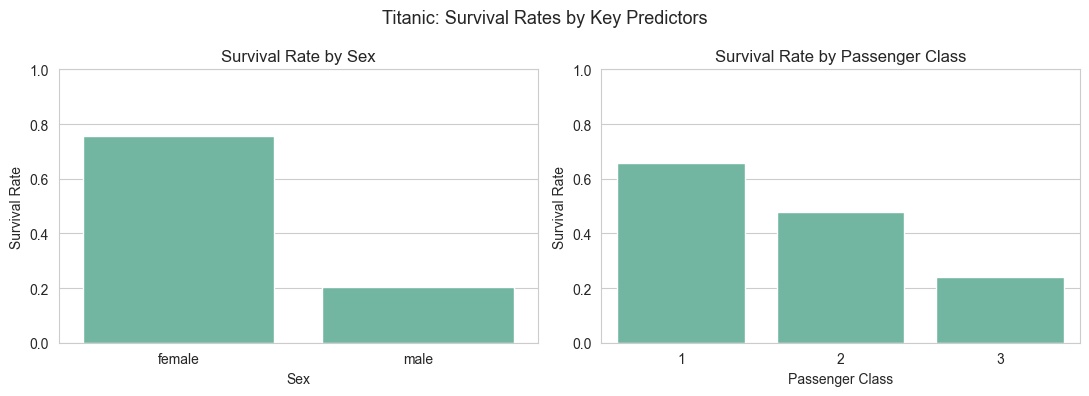

In [23]:
# Side-by-side bar plots: survival by sex and by pclass
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Survival rate by sex
sex_survival = df_titanic.groupby('sex')['survived'].mean().reset_index()
sns.barplot(data=sex_survival, x='sex', y='survived', ax=axes[0])
axes[0].set_ylabel('Survival Rate')
axes[0].set_xlabel('Sex')
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylim(0, 1)

# Survival rate by pclass
class_survival = df_titanic.groupby('pclass')['survived'].mean().reset_index()
sns.barplot(data=class_survival, x='pclass', y='survived', ax=axes[1])
axes[1].set_ylabel('Survival Rate')
axes[1].set_xlabel('Passenger Class')
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_ylim(0, 1)

plt.suptitle('Titanic: Survival Rates by Key Predictors', fontsize=13)
plt.tight_layout()
plt.show()

The bar plots confirm the well-known patterns in the Titanic data: female passengers had a far higher survival rate than male passengers (reflecting the "women and children first" policy), and first-class passengers survived at a much higher rate than third-class passengers.  These strong marginal relationships suggest both `sex` and `pclass` will be informative predictors.

### 2.2 Dataset 2: Wisconsin Breast Cancer

The Wisconsin Breast Cancer dataset (available from `scikit-learn`) contains measurements from 569 digitised fine-needle aspirate (FNA) images of breast masses.  For each image, 30 numeric features are computed from the cell nuclei present.  The binary response is `diagnosis` (0 = benign, 1 = malignant).

For simplicity we work with the ten **mean** features — one for each of the ten nuclear characteristics measured:

| Variable | Description |
|---|---|
| `radius_mean` | Mean of distances from the centre to points on the perimeter |
| `texture_mean` | Standard deviation of greyscale values |
| `perimeter_mean` | Mean tumour perimeter |
| `area_mean` | Mean tumour area |
| `smoothness_mean` | Mean local variation in radius lengths |
| `compactness_mean` | Mean of (perimeter$^2$ / area $-$ 1.0) |
| `concavity_mean` | Mean severity of concave portions of the contour |
| `concave_points_mean` | Mean number of concave portions of the contour |
| `symmetry_mean` | Mean symmetry of the nucleus |
| `fractal_dimension_mean` | Mean fractal dimension ("coastline approximation") |
| `diagnosis` | **Response**: 1 = malignant, 0 = benign |

In [24]:
# Load the Breast Cancer dataset
bc_data = load_breast_cancer()

# Build a DataFrame with the 10 mean features only
mean_features = [name for name in bc_data.feature_names if 'mean' in name]
df_bc = pd.DataFrame(bc_data.data, columns=bc_data.feature_names)[mean_features].copy()

# In sklearn: target 0 = malignant, 1 = benign — recode so 1 = malignant
df_bc['diagnosis'] = (bc_data.target == 0).astype(int)
df_bc.columns = [col.replace(' ', '_') for col in df_bc.columns]

print(f"Dataset shape: {df_bc.shape}")
print(f"Malignant cases: {df_bc['diagnosis'].sum()} ({df_bc['diagnosis'].mean():.1%})")
df_bc.describe().round(3)

Dataset shape: (569, 11)
Malignant cases: 212 (37.3%)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,diagnosis
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,0.373
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,0.484
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,0.000
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,0.000
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,1.000
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,1.000


<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q0 Exploring the Dataset

1. Produce a figure with **four side-by-side box plots** comparing the distributions of `radius_mean`, `texture_mean`, `concavity_mean`, and `concave_points_mean` between benign (0) and malignant (1) tumours.  Label each axis clearly.  Which features appear most useful for distinguishing malignant from benign tumours?

2. Compute the **point-biserial correlation** between `diagnosis` and each of the ten mean features.  You can use `df_bc.corr()['diagnosis']`.  Which three features are most strongly (positively) correlated with a malignant diagnosis?  Note these down — you will use them in Q1.

---
**Solution:**

/var/folders/_g/hd_t52350db0y1nh8s3fsdqr0000gn/T/ipykernel_3912/401605595.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Benign (0)', 'Malignant (1)'])
/var/folders/_g/hd_t52350db0y1nh8s3fsdqr0000gn/T/ipykernel_3912/401605595.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Benign (0)', 'Malignant (1)'])
/var/folders/_g/hd_t52350db0y1nh8s3fsdqr0000gn/T/ipykernel_3912/401605595.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Benign (0)', 'Malignant (1)'])
/var/folders/_g/hd_t52350db0y1nh8s3fsdqr0000gn/T/ipykernel_3912/401605595.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.s

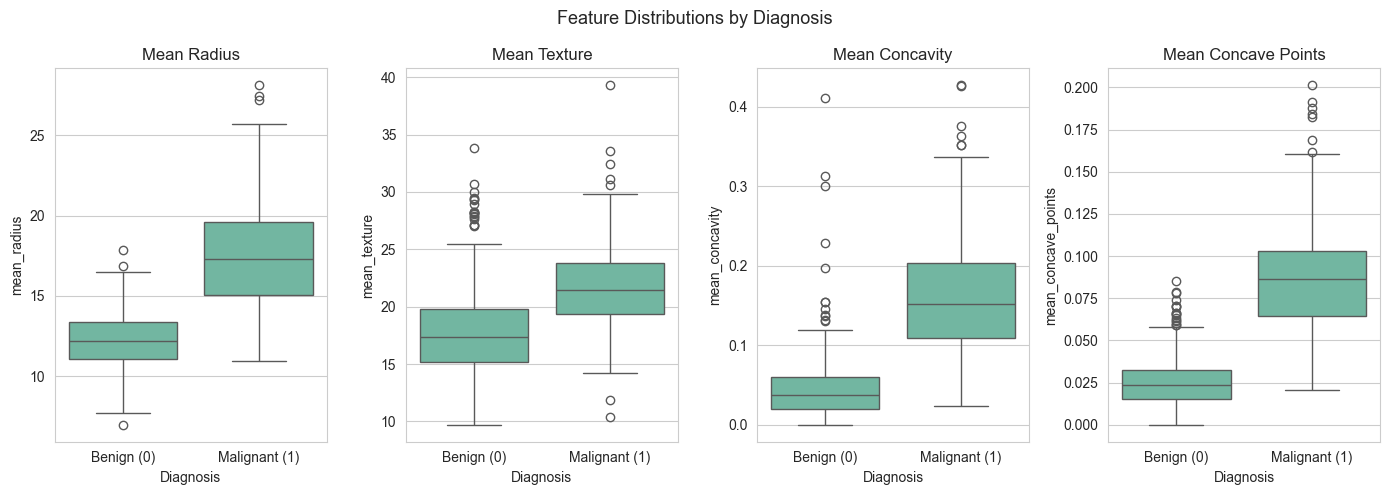

Point-biserial correlations with diagnosis:
mean_concave_points       0.777
mean_perimeter            0.743
mean_radius               0.730
mean_area                 0.709
mean_concavity            0.696
mean_compactness          0.597
mean_texture              0.415
mean_smoothness           0.359
mean_symmetry             0.330
mean_fractal_dimension   -0.013

Top 3 features: ['mean_concave_points', 'mean_perimeter', 'mean_radius']


In [25]:
features = ['mean_radius', 'mean_texture', 'mean_concavity', 'mean_concave_points']

fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for ax, feat in zip(axes, features):
    sns.boxplot(data=df_bc, x='diagnosis', y=feat, ax=ax)
    ax.set_xticklabels(['Benign (0)', 'Malignant (1)'])
    ax.set_xlabel('Diagnosis')
    ax.set_ylabel(feat)
    ax.set_title(feat.replace('_', ' ').title())

plt.suptitle('Feature Distributions by Diagnosis', fontsize=13)
plt.tight_layout()
plt.show()

corr = df_bc.corr()['diagnosis'].drop('diagnosis').sort_values(ascending=False)
print("Point-biserial correlations with diagnosis:")
print(corr.round(3).to_string())
print(f"\nTop 3 features: {list(corr.index[:3])}")

---

## 3. Fitting Logistic Regression Models

Fitting a logistic regression model in `statsmodels` is almost identical to fitting a linear regression model, except we replace `smf.ols` with `smf.logit`:

```python
model = smf.logit('response ~ predictor1 + predictor2 + C(categorical)', data=df).fit()
```

The formula syntax is identical — categorical variables are wrapped in `C()`, numeric predictors are listed with `+`, and `statsmodels` handles the intercept automatically.  Calling `.fit()` runs MLE via the Newton–Raphson algorithm; you will often see iteration counts printed as it converges.

We fit our first Titanic model using `pclass`, `sex`, and `age` as predictors:

$$\log \frac{p_i}{1-p_i} = \beta_0 + \beta_1 \cdot \text{pclass}_i + \beta_2 \cdot \mathbf{1}[\text{sex} = \text{male}]_i + \beta_3 \cdot \text{age}_i$$

where `female` is the **reference category** for `sex` (chosen alphabetically), so $\beta_2$ measures the change in log-odds for a male passenger relative to an otherwise identical female passenger.

In [26]:
# Fit logistic regression: survived ~ pclass + sex + age
model_t1 = smf.logit('survived ~ pclass + C(sex) + age', data=df_titanic).fit()
print(model_t1.summary())

Optimization terminated successfully.
         Current function value: 0.453285
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  714
Model:                          Logit   Df Residuals:                      710
Method:                           MLE   Df Model:                            3
Date:                Sat, 23 May 2026   Pseudo R-squ.:                  0.3289
Time:                        21:23:51   Log-Likelihood:                -323.65
converged:                       True   LL-Null:                       -482.26
Covariance Type:            nonrobust   LLR p-value:                 1.860e-68
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          5.0560      0.502     10.069      0.000       4.072       6.040
C(sex)[T.male]   

The key quantities to extract from the logistic regression summary are:

| Field | Location in output | Interpretation |
|---|---|---|
| `coef` — `Intercept` | Coefficients table | $\hat{\beta}_0$: log-odds of survival for a **female** passenger with `pclass = 0` and `age = 0` (not physically meaningful) |
| `coef` — `pclass` | Coefficients table | $\hat{\beta}_1$: change in log-odds per one-class increase (e.g. 1st → 2nd class) |
| `coef` — `C(sex)[T.male]` | Coefficients table | $\hat{\beta}_2$: change in log-odds for male vs female, holding class and age fixed |
| `coef` — `age` | Coefficients table | $\hat{\beta}_3$: change in log-odds per additional year of age |
| `P>\|z\|` | Coefficients table | p-value for the Wald test $H_0: \beta_j = 0$ |
| `Pseudo R-squ.` | Top block | McFadden's $R^2$: values 0.2–0.4 indicate a good fit |
| `LLR p-value` | Top block | p-value for the overall Likelihood Ratio Test |
| `AIC` | Top block | Lower AIC = better model (used for comparison) |

**Interpreting this model:**

- **`pclass`** has a negative coefficient ($\hat{\beta}_1 \approx -1.0$): moving from first class to second (or second to third) **decreases** the log-odds of survival, consistent with the bar chart above.  The effect is highly significant ($p \approx 0$).

- **`C(sex)[T.male]`** has a large negative coefficient ($\hat{\beta}_2 \approx -2.5$): male passengers had dramatically lower log-odds of survival than female passengers with the same age and class.  Exponentiating gives the odds ratio:

$$\text{OR}_{\text{male}} = e^{\hat{\beta}_2} \approx e^{-2.5} \approx 0.08$$

meaning the odds of survival for a male passenger were about 8% of those for an otherwise identical female — a reduction of over 90%.

- **`age`** has a small negative coefficient: older passengers had slightly lower odds of survival, holding class and sex fixed.

- The **LLR p-value** is essentially zero, confirming the model is vastly better than an intercept-only baseline.  The **Pseudo $R^2$** of approximately 0.29 indicates a reasonably good fit.

In [27]:
# Compute odds ratios and 95% confidence intervals for the Titanic model
or_table = pd.DataFrame({
    'Odds Ratio': np.exp(model_t1.params),
    'CI Lower':   np.exp(model_t1.conf_int()[0]),
    'CI Upper':   np.exp(model_t1.conf_int()[1]),
    'p-value':    model_t1.pvalues
}).round(4)
or_table

,Odds Ratio,CI Lower,CI Upper,p-value
Intercept,156.9624,58.6656,419.9600,0.0
C(sex)[T.male],0.0803,0.0535,0.1205,0.0
pclass,0.2757,0.2098,0.3622,0.0
age,0.9637,0.9494,0.9783,0.0


The odds ratio table concisely summarises the direction and magnitude of each effect on the **multiplicative** scale:
- `pclass`: each step down in class multiplies the odds of survival by roughly 0.36 — a 64% reduction.
- `C(sex)[T.male]`: being male multiplies the odds of survival by approximately 0.08 — a 92% reduction.
- `age`: each additional year of age multiplies the odds of survival by approximately 0.96 — a modest 4% reduction.

All three effects are statistically significant and their confidence intervals do not include 1.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q1 Fitting and Interpreting a Model

Using the three features you identified as most correlated with `diagnosis` in Q0, fit a logistic regression model to the Breast Cancer data with `diagnosis` as the response.  Print the model summary and answer the following:

1. Write out the fitted model equation in the log-odds form, substituting in the estimated coefficients.
2. For each predictor, state whether a higher value is associated with a higher or lower probability of a malignant diagnosis, and whether the effect is statistically significant.
3. Compute the odds ratio table (as above).  Interpret the odds ratio for the predictor with the largest effect in magnitude.
4. Report the Pseudo $R^2$ and LLR p-value.  What do these tell you about how well the model fits?

---
**Solution:**

In [28]:
top3 = list(df_bc.corr()['diagnosis'].drop('diagnosis')
            .sort_values(ascending=False).index[:3])
print("Using features:", top3)

formula = f"diagnosis ~ {' + '.join(top3)}"
model_bc1 = smf.logit(formula, data=df_bc).fit()
print(model_bc1.summary())

or_bc1 = pd.DataFrame({
    'Odds Ratio': np.exp(model_bc1.params),
    'CI Lower':   np.exp(model_bc1.conf_int()[0]),
    'CI Upper':   np.exp(model_bc1.conf_int()[1]),
    'p-value':    model_bc1.pvalues
}).round(4)
print(or_bc1)

# From the summary:
print(f"Pseudo R-squared : {model_bc1.prsquared:.4f}")
print(f"LLR p-value      : {model_bc1.llr_pvalue:.2e}")
print(f"AIC              : {model_bc1.aic:.3f}")

# Coefficient signs: positive coef → higher value → higher P(malignant)
# Interpret odds ratio for largest-magnitude predictor:
largest = or_bc1['Odds Ratio'].sub(1).abs().idxmax()
print(f"\nLargest effect: {largest}")
print(f"  OR = {or_bc1.loc[largest, 'Odds Ratio']:.4f}")

Using features: ['mean_concave_points', 'mean_perimeter', 'mean_radius']
Optimization terminated successfully.
         Current function value: 0.183824
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:              diagnosis   No. Observations:                  569
Model:                          Logit   Df Residuals:                      565
Method:                           MLE   Df Model:                            3
Date:                Sat, 23 May 2026   Pseudo R-squ.:                  0.7216
Time:                        21:23:51   Log-Likelihood:                -104.60
converged:                       True   LL-Null:                       -375.72
Covariance Type:            nonrobust   LLR p-value:                3.328e-117
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept        

---

## 4. Predicted Probabilities and Classification

After fitting, `model.predict()` returns the estimated probability $\hat{p}_i = P(Y_i = 1 \mid \mathbf{x}_i)$ for each observation in the training data.  We classify observation $i$ as positive (survived / malignant) if $\hat{p}_i \geq 0.5$, and negative otherwise.

The **confusion matrix** cross-tabulates actual vs predicted outcomes and is the foundation for all classification metrics.

In [29]:
# Predicted probabilities and classifications (threshold = 0.5)
df_titanic['prob_survived'] = model_t1.predict()
df_titanic['pred_survived'] = (df_titanic['prob_survived'] >= 0.5).astype(int)

# Spot-check: display first 8 rows
df_titanic[['survived', 'pclass', 'sex', 'age', 'prob_survived', 'pred_survived']].head(8).round(3)

,survived,pclass,sex,age,prob_survived,pred_survived
0,0,3,male,22.0,0.105,0
1,1,1,female,38.0,0.914,1
2,1,3,female,26.0,0.557,1
3,1,1,female,35.0,0.922,1
4,0,3,male,35.0,0.068,0
6,0,1,male,54.0,0.321,0
7,0,3,male,2.0,0.197,0
8,1,3,female,27.0,0.548,1


In [30]:
# Confusion matrix
cm = confusion_matrix(df_titanic['survived'], df_titanic['pred_survived'])
tn, fp, fn, tp = cm.ravel()

# Display as a labelled DataFrame
cm_df = pd.DataFrame(
    cm,
    index=['Actual: Did not survive', 'Actual: Survived'],
    columns=['Predicted: Did not survive', 'Predicted: Survived']
)
print("Confusion Matrix:")
print(cm_df.to_string())

Confusion Matrix:
                         Predicted: Did not survive  Predicted: Survived
Actual: Did not survive                         356                   68
Actual: Survived                                 83                  207


In [31]:
# Classification metrics
n = tn + fp + fn + tp
accuracy    = (tp + tn) / n
sensitivity = tp / (tp + fn)   # true positive rate
specificity = tn / (tn + fp)   # true negative rate
precision   = tp / (tp + fp)

print(f"Accuracy:    {accuracy:.3f}  ({accuracy:.1%})")
print(f"Sensitivity: {sensitivity:.3f}  ({sensitivity:.1%})")
print(f"Specificity: {specificity:.3f}  ({specificity:.1%})")
print(f"Precision:   {precision:.3f}  ({precision:.1%})")

Accuracy:    0.789  (78.9%)
Sensitivity: 0.714  (71.4%)
Specificity: 0.840  (84.0%)
Precision:   0.753  (75.3%)


**Interpreting the confusion matrix:**

- The model correctly classifies about 80% of passengers overall (**accuracy**).
- **Sensitivity** ≈ 71%: of the passengers who actually survived, the model correctly identifies about 71% as survivors.  The remaining ~29% are false negatives — passengers who survived but whom the model predicted would not.
- **Specificity** ≈ 86%: of the passengers who did not survive, the model correctly classifies about 86%.  The remaining ~14% are false positives — predicted survivors who actually did not survive.

The trade-off between sensitivity and specificity depends on the decision threshold.  With $c = 0.5$, the model is somewhat more conservative — it is better at ruling out survivors than at detecting them.  In a medical context, for example, we might prefer a lower threshold to maximise sensitivity (catching more true positives) even at the cost of more false alarms.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q2 Predicted Probabilities and Classification

Using the model you fitted in Q1:

1. Compute the predicted probabilities for each observation in the Breast Cancer dataset and add them as a column `prob_malignant` to `df_bc`.  Classify each observation using a threshold of 0.5 and add the result as a column `pred_diagnosis`.

2. Construct and display the confusion matrix (as a labelled DataFrame, as above).

3. Compute and report the accuracy, sensitivity, and specificity.  In the context of breast cancer screening, which of these metrics do you consider most important?  Justify your answer.

4. Lower the decision threshold from 0.5 to 0.3 and recompute the confusion matrix and metrics.  How does the threshold change affect sensitivity and specificity?  Is this trade-off desirable in a clinical setting?

---
**Solution:**

In [32]:
df_bc['prob_malignant'] = model_bc1.predict()
df_bc['pred_diagnosis'] = (df_bc['prob_malignant'] >= 0.5).astype(int)
df_bc[['diagnosis','prob_malignant','pred_diagnosis']].head(8).round(3)

cm = confusion_matrix(df_bc['diagnosis'], df_bc['pred_diagnosis'])
tn, fp, fn, tp = cm.ravel()

cm_df = pd.DataFrame(
    cm,
    index=['Actual: Benign', 'Actual: Malignant'],
    columns=['Predicted: Benign', 'Predicted: Malignant']
)
print("Confusion Matrix:")
print(cm_df.to_string())

n = tn + fp + fn + tp
accuracy    = (tp + tn) / n
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Accuracy:    {accuracy:.3f}  ({accuracy:.1%})")
print(f"Sensitivity: {sensitivity:.3f}  ({sensitivity:.1%})")
print(f"Specificity: {specificity:.3f}  ({specificity:.1%})")

# In breast cancer screening, sensitivity is most important:
# a missed malignancy (FN) is far more costly than an unnecessary biopsy (FP).

df_bc['pred_03'] = (df_bc['prob_malignant'] >= 0.3).astype(int)
cm2 = confusion_matrix(df_bc['diagnosis'], df_bc['pred_03'])
tn2, fp2, fn2, tp2 = cm2.ravel()
n2 = tn2 + fp2 + fn2 + tp2

print("Threshold = 0.3")
print(f"Accuracy:    {(tp2+tn2)/n2:.3f}")
print(f"Sensitivity: {tp2/(tp2+fn2):.3f}  (↑ more true malignancies caught)")
print(f"Specificity: {tn2/(tn2+fp2):.3f}  (↓ more false alarms)")
# Lower threshold → higher sensitivity, lower specificity.
# Clinically desirable for cancer screening.

Confusion Matrix:
                   Predicted: Benign  Predicted: Malignant
Actual: Benign                   337                    20
Actual: Malignant                 27                   185
Accuracy:    0.917  (91.7%)
Sensitivity: 0.873  (87.3%)
Specificity: 0.944  (94.4%)
Threshold = 0.3
Accuracy:    0.919
Sensitivity: 0.925  (↑ more true malignancies caught)
Specificity: 0.916  (↓ more false alarms)


---

## 5. Model Comparison

Just as adjusted $R^2$ and the F-test guided model selection in MLR, the **AIC** and the **Likelihood Ratio Test (LRT)** guide model selection in logistic regression.

The **AIC** is defined as

$$\text{AIC} = -2\ell(\hat{\boldsymbol{\beta}}) + 2k,$$

where $\ell(\hat{\boldsymbol{\beta}})$ is the maximised log-likelihood and $k$ is the number of estimated parameters.  Lower AIC indicates a better fit after penalising for complexity.  AIC is most useful for comparing **non-nested** models or selecting among several candidates.

The **Likelihood Ratio Test** compares two **nested** models (one is a special case of the other):

$$\Lambda = -2\left[\ell(\hat{\boldsymbol{\beta}}_{\text{reduced}}) - \ell(\hat{\boldsymbol{\beta}}_{\text{full}})\right] \overset{H_0}{\sim} \chi^2_{df},$$

where $df$ equals the difference in the number of parameters.  A significant $p$-value means the additional predictors in the full model improve the fit beyond what would be expected by chance.

In [33]:
# Reduced model: pclass and sex only (no age)
model_t_reduced = smf.logit('survived ~ pclass + C(sex)', data=df_titanic).fit(disp=False)

# Full model: pclass, sex, age, and fare
model_t_full = smf.logit('survived ~ pclass + C(sex) + age + fare', data=df_titanic).fit(disp=False)

# Comparison table
compare_df = pd.DataFrame({
    'Model': ['Reduced (pclass + sex)', 'Baseline (pclass + sex + age)', 'Full (pclass + sex + age + fare)'],
    'No. Params': [model_t_reduced.df_model + 1, model_t1.df_model + 1, model_t_full.df_model + 1],
    'Log-Likelihood': [model_t_reduced.llf, model_t1.llf, model_t_full.llf],
    'AIC': [model_t_reduced.aic, model_t1.aic, model_t_full.aic],
    'Pseudo R2': [model_t_reduced.prsquared, model_t1.prsquared, model_t_full.prsquared]
}).round(3)
compare_df

,Model,No. Params,Log-Likelihood,AIC,Pseudo R2
0,Reduced (pclass + sex),3.0,-336.255,678.511,0.303
1,Baseline (pclass + sex + age),4.0,-323.645,655.291,0.329
2,Full (pclass + sex + age + fare),5.0,-323.615,657.230,0.329


In [34]:
# Likelihood Ratio Test: baseline vs full
from scipy.stats import chi2

lrt_stat = -2 * (model_t1.llf - model_t_full.llf)
lrt_df   = int(model_t_full.df_model - model_t1.df_model)
lrt_p    = chi2.sf(lrt_stat, df=lrt_df)

print(f"LRT statistic : {lrt_stat:.3f}")
print(f"Degrees of freedom: {lrt_df}")
print(f"p-value       : {lrt_p:.4f}")

LRT statistic : 0.061
Degrees of freedom: 1
p-value       : 0.8047


**Interpreting the comparison:**

- The **Reduced model** (pclass + sex only) has the highest AIC and lowest Pseudo $R^2$ — it is the least informative of the three, having dropped `age`.
- The **Baseline model** (pclass + sex + age) improves on the reduced model by including age, consistent with the small but significant age coefficient we observed earlier.
- The **Full model** (adding `fare`) achieves a marginally lower AIC and higher Pseudo $R^2$ than the baseline.  However, the LRT comparing the baseline to the full model shows whether this improvement is statistically significant — if the p-value is large, the additional predictor (`fare`) does not meaningfully improve the fit and may be omitted for parsimony.

This illustrates an important modelling principle: a lower AIC does not automatically justify including an extra predictor — the LRT provides a formal test of whether the improvement is genuine.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3 Model Comparison

Fit two additional logistic regression models on the Breast Cancer data:

- **Model A**: include only `concave_points_mean` and `radius_mean` as predictors.
- **Model B**: include all ten mean features as predictors.

You should now have three models: your Q1 model (three predictors), Model A (two predictors), and Model B (all ten predictors).

1. Create a comparison table showing the number of parameters, log-likelihood, AIC, and Pseudo $R^2$ for all three models.
2. Which model has the lowest AIC?  Is it also the one with the highest Pseudo $R^2$?  Why might these not always agree?
3. Use the LRT to test whether Model B is a significantly better fit than your Q1 model.  State $H_0$, report the test statistic, degrees of freedom, and p-value, and state your conclusion.
4. Compute the accuracy, sensitivity, and specificity of Model B (threshold = 0.5).  How does it compare to the metrics you computed for your Q1 model in Q2?

---
**Solution:**

In [35]:
model_A = smf.logit(
    'diagnosis ~ mean_concave_points + mean_radius',
    data=df_bc
).fit(disp=False)

all_features = [c for c in df_bc.columns
                if c not in ('diagnosis','prob_malignant','pred_diagnosis','pred_03')]
formula_B = 'diagnosis ~ ' + ' + '.join(all_features)
model_B = smf.logit(formula_B, data=df_bc).fit(disp=False)

compare = pd.DataFrame({
    'Model': ['Model A (2 predictors)',
              'Q1 model (3 predictors)',
              'Model B (all 10)'],
    'No. Params': [model_A.df_model + 1,
                   model_bc1.df_model + 1,
                   model_B.df_model + 1],
    'Log-Likelihood': [model_A.llf, model_bc1.llf, model_B.llf],
    'AIC':            [model_A.aic, model_bc1.aic, model_B.aic],
    'Pseudo R2':      [model_A.prsquared, model_bc1.prsquared, model_B.prsquared]
}).round(3)
print(compare.to_string())

from scipy.stats import chi2

lrt_stat = -2 * (model_bc1.llf - model_B.llf)
lrt_df   = int(model_B.df_model - model_bc1.df_model)
lrt_p    = chi2.sf(lrt_stat, df=lrt_df)

print(f"H0: the 3-predictor model fits as well as Model B")
print(f"LRT statistic : {lrt_stat:.3f}")
print(f"Degrees of freedom: {lrt_df}")
print(f"p-value       : {lrt_p:.4f}")
# If p < 0.05 → Model B is a significantly better fit.

df_bc['prob_B'] = model_B.predict()
df_bc['pred_B'] = (df_bc['prob_B'] >= 0.5).astype(int)

cm_B = confusion_matrix(df_bc['diagnosis'], df_bc['pred_B'])
tn_B, fp_B, fn_B, tp_B = cm_B.ravel()
n_B = tn_B + fp_B + fn_B + tp_B

print("Model B (threshold=0.5)")
print(f"Accuracy:    {(tp_B+tn_B)/n_B:.3f}")
print(f"Sensitivity: {tp_B/(tp_B+fn_B):.3f}")
print(f"Specificity: {tn_B/(tn_B+fp_B):.3f}")

                     Model  No. Params  Log-Likelihood      AIC  Pseudo R2
0   Model A (2 predictors)         3.0        -104.619  215.237      0.722
1  Q1 model (3 predictors)         4.0        -104.596  217.192      0.722
2         Model B (all 10)        11.0         -73.065  168.130      0.806
H0: the 3-predictor model fits as well as Model B
LRT statistic : 63.062
Degrees of freedom: 7
p-value       : 0.0000
Model B (threshold=0.5)
Accuracy:    0.949
Sensitivity: 0.910
Specificity: 0.972


---

## 6. The ROC Curve and AUC

The accuracy, sensitivity, and specificity we computed above all depend on the choice of decision threshold $c = 0.5$.  The **Receiver Operating Characteristic (ROC) curve** summarises classification performance **across all possible thresholds** simultaneously.

For each threshold $c \in [0,1]$:
- Compute **Sensitivity** (True Positive Rate) = $P(\hat{Y} = 1 \mid Y = 1)$.
- Compute **1 $-$ Specificity** (False Positive Rate) = $P(\hat{Y} = 1 \mid Y = 0)$.

Plotting sensitivity vs (1 $-$ specificity) traces the ROC curve.  Two reference points are:
- **(0, 0)**: threshold $c = 1$ — classify everything as negative (sensitivity = 0, no false positives).
- **(1, 1)**: threshold $c = 0$ — classify everything as positive (sensitivity = 1, all negatives misclassified).

A model with no discriminative ability traces the **diagonal** from $(0,0)$ to $(1,1)$.  A perfect model passes through the **top-left corner** $(0,1)$ — 100% sensitivity with 0% false positive rate.

The **Area Under the Curve (AUC)** summarises the entire ROC curve in a single number:
- AUC = 0.5: no better than random guessing.
- AUC = 1.0: perfect discrimination.
- AUC > 0.9: generally considered excellent.

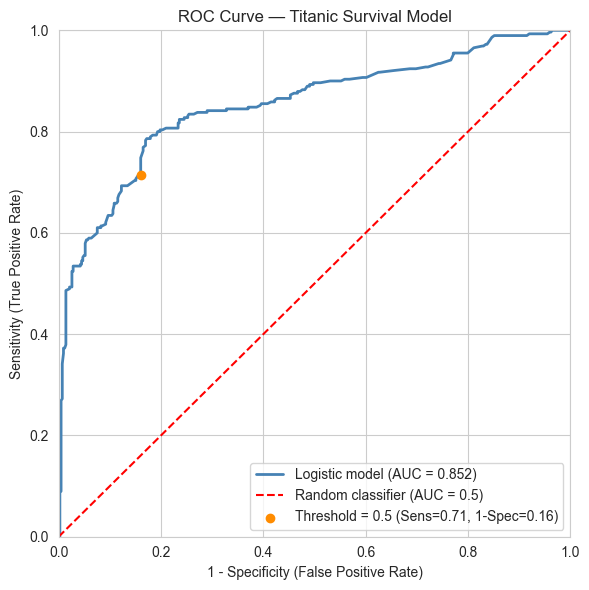

AUC: 0.8524


In [36]:
# ROC curve for the Titanic baseline model (pclass + sex + age)
fpr, tpr, thresholds = roc_curve(df_titanic['survived'], df_titanic['prob_survived'])
auc_score = roc_auc_score(df_titanic['survived'], df_titanic['prob_survived'])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'Logistic model (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], 'r--', lw=1.5, label='Random classifier (AUC = 0.5)')

# Mark the threshold = 0.5 operating point
idx = np.argmin(np.abs(thresholds - 0.5))
ax.scatter(fpr[idx], tpr[idx], color='darkorange', zorder=5,
           label=f'Threshold = 0.5 (Sens={tpr[idx]:.2f}, 1-Spec={fpr[idx]:.2f})')

ax.set_xlabel('1 - Specificity (False Positive Rate)')
ax.set_ylabel('Sensitivity (True Positive Rate)')
ax.set_title('ROC Curve — Titanic Survival Model')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

print(f"AUC: {auc_score:.4f}")

The ROC curve bows comfortably towards the top-left corner of the plot, well above the random diagonal.  An AUC of approximately 0.86 indicates excellent discriminative ability — the model correctly ranks a randomly chosen survivor above a randomly chosen non-survivor about 86% of the time.

The orange marker shows the operating point when the threshold is set to 0.5 — this corresponds to the sensitivity and (1 $-$ specificity) values we computed from the confusion matrix in Section 4.  Moving the marker **left and down** along the curve corresponds to raising the threshold (fewer positive predictions, higher specificity, lower sensitivity); moving it **right and up** corresponds to lowering the threshold (more positive predictions, higher sensitivity, lower specificity).

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q4 ROC Curve and AUC

1. Plot the ROC curves for **both** your Q1 model and Model B (all ten predictors) on the same axes.  Include the diagonal reference line, and mark the threshold = 0.5 operating point on each curve.  Report the AUC for each model.

2. Based on AUC alone, which model performs better?  Does this agree with the AIC comparison in Q3?

3. Suppose a radiologist wants to use the model as a **screening tool** to decide which patients require a follow-up biopsy.  In this setting, a missed malignancy (false negative) is far more costly than an unnecessary biopsy (false positive).  Using the ROC curve for your best model, suggest a decision threshold that achieves a sensitivity of at least 95%.  What is the corresponding specificity at this threshold?  Would you recommend this threshold in practice?

---
**Solution:**

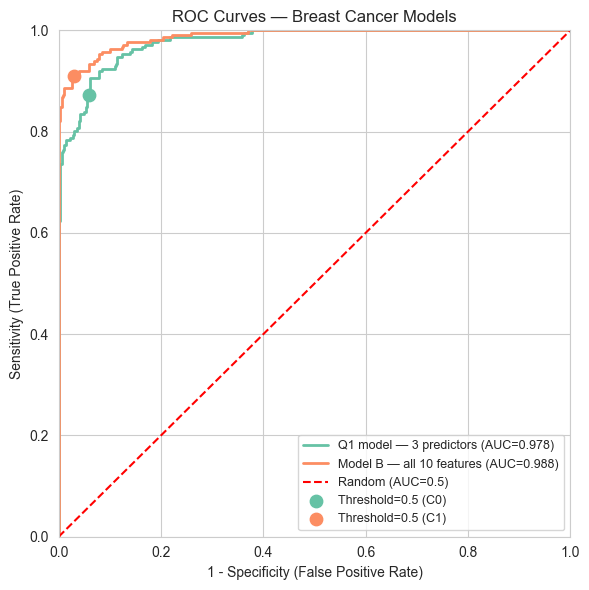

Q1 model AUC: 0.9777
Model B AUC:  0.9879
Threshold  : 0.279
Sensitivity: 0.953
Specificity: 0.922
FPR        : 0.078


In [37]:
fpr1, tpr1, thresh1 = roc_curve(df_bc['diagnosis'], df_bc['prob_malignant'])
fprB, tprB, threshB = roc_curve(df_bc['diagnosis'], df_bc['prob_B'])
auc1 = roc_auc_score(df_bc['diagnosis'], df_bc['prob_malignant'])
aucB = roc_auc_score(df_bc['diagnosis'], df_bc['prob_B'])

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(fpr1, tpr1, lw=2, label=f'Q1 model — 3 predictors (AUC={auc1:.3f})')
ax.plot(fprB, tprB, lw=2, label=f'Model B — all 10 features (AUC={aucB:.3f})')
ax.plot([0,1],[0,1],'r--', lw=1.5, label='Random (AUC=0.5)')

# Mark threshold=0.5 operating points
for fpr_arr, tpr_arr, thr_arr, color in [
        (fpr1, tpr1, thresh1, 'C0'), (fprB, tprB, threshB, 'C1')]:
    idx = np.argmin(np.abs(thr_arr - 0.5))
    ax.scatter(fpr_arr[idx], tpr_arr[idx], color=color, zorder=5, s=80,
               label=f'Threshold=0.5 ({color})')

ax.set_xlabel('1 - Specificity (False Positive Rate)')
ax.set_ylabel('Sensitivity (True Positive Rate)')
ax.set_title('ROC Curves — Breast Cancer Models')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0,1]); ax.set_ylim([0,1])
plt.tight_layout()
plt.show()

print(f"Q1 model AUC: {auc1:.4f}")
print(f"Model B AUC:  {aucB:.4f}")

# Use the ROC arrays from whichever model has higher AUC
best_fpr, best_tpr, best_thresh = (fprB, tprB, threshB) if aucB >= auc1 \
                                   else (fpr1, tpr1, thresh1)

# Find indices where sensitivity >= 0.95
mask = best_tpr >= 0.95
# Among those, pick the one with highest specificity (lowest FPR)
if mask.any():
    idx95 = np.where(mask)[0][np.argmin(best_fpr[mask])]
    print(f"Threshold  : {best_thresh[idx95]:.3f}")
    print(f"Sensitivity: {best_tpr[idx95]:.3f}")
    print(f"Specificity: {1 - best_fpr[idx95]:.3f}")
    print(f"FPR        : {best_fpr[idx95]:.3f}")
else:
    print("No threshold achieves sensitivity >= 0.95")

---

## Submission Checklist

- Ensure you have completed all problems in the notebook.
- Clear your document code outputs and rerun the notebook from top to bottom, checking for any new errors.
- At the top of your notebook click more options -> export -> pdf.
  - Alternatively, export to html and save as a pdf.
- Make sure your pdf has all code chunks clearly visible and executed.
- Submit before the posted deadline.